In [1]:
import cv2
import matplotlib.pyplot as plt

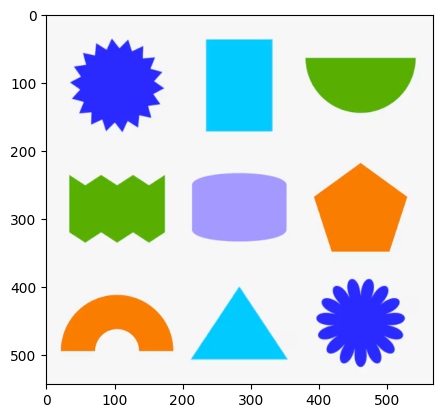

In [3]:
image = cv2.imread('./assets/shape2.png')
plt.imshow(image)

In [4]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

Text(0.5, 1.0, 'RGB Image')

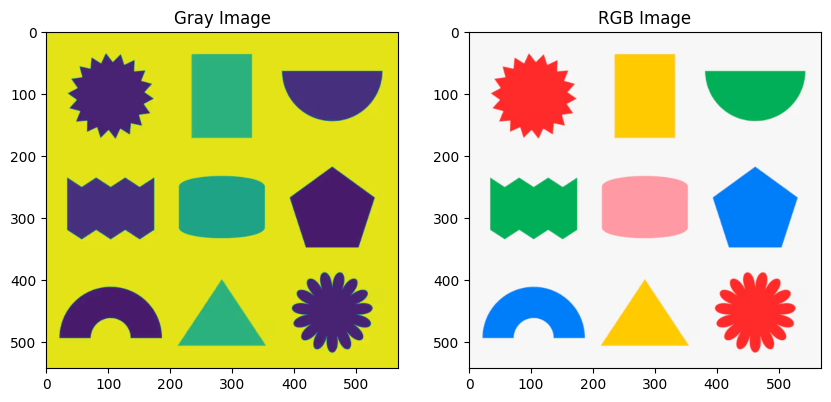

In [8]:
plt.figure(figsize=(10, 8))

plt.subplot(1, 2, 1)
plt.imshow(image_gray)
plt.title("Gray Image")

plt.subplot(1, 2, 2)
plt.imshow(image_rgb)
plt.title("RGB Image")

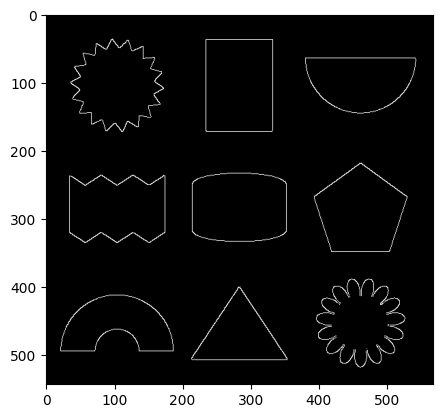

In [ ]:
gray = cv2.Canny(image_gray, 80, 150)
plt.imshow(gray, cmap="gray")

In [16]:
"""
cv2.findContours(image, mode, method)

cv2.RETR_EXTERNAL
শুধুমাত্র বাইরের (external) কন্টুর গুলো খুঁজে বের করে। ভিতরের যেগুলো নেস্টেড থাকে, সেগুলো উপেক্ষা করা হয়।
📌 ব্যবহার: বাউন্ডারি বের করতে চাইলে।

2. cv2.RETR_LIST
ছবির সব কন্টুর খুঁজে বের করে, কিন্তু তাদের মধ্যে কোন parent-child সম্পর্ক রাখে না।
📌 ব্যবহার: সব কন্টুর দরকার, কিন্তু সম্পর্ক দরকার নেই।

3. cv2.RETR_TREE
সব কন্টুর খুঁজে বের করে এবং তাদের parent-child (hierarchy) সম্পর্কসহ দেয়।
📌 ব্যবহার: যখন nested structure দরকার (যেমন: গর্ত বা ফাঁপা বস্তু)।

4. cv2.RETR_CCOMP
কন্টুর গুলোকে দুটি স্তরে ভাগ করে: বাইরেরগুলো এক লেভেলে এবং ভিতরেরগুলো অন্য লেভেলে।
📌 ব্যবহার: 2-লেভেল হায়ারার্কি দরকার হলে।

-----
Method 
1. cv2.CHAIN_APPROX_NONE
প্রতিটি কন্টুর পয়েন্ট সংরক্ষণ করে, অর্থাৎ কোন পয়েন্ট বাদ দেয় না। অনেক বেশি মেমোরি ব্যবহার করে।
📌 ব্যবহার: যখন প্রতিটি পিক্সেল পয়েন্ট দরকার হয়।

🔹 2. cv2.CHAIN_APPROX_SIMPLE
অপ্রয়োজনীয় পয়েন্টগুলো বাদ দিয়ে কেবল গুরুত্বপূর্ণ কোণার পয়েন্ট (corner points) রাখে।
📌 ব্যবহার: সাধারণত সবচেয়ে বেশি ব্যবহার হয়।

🔹 3. cv2.CHAIN_APPROX_TC89_L1 এবং cv2.CHAIN_APPROX_TC89_KCOS
এগুলো Teh-Chin কন্টুর অ্যাপ্রোক্সিমেশন অ্যালগরিদম ব্যবহার করে, যেটা আরও কম পয়েন্টে কন্টুর প্রকাশ করে।
📌 ব্যবহার: High-level approximation দরকার হলে।

"""


contours, hierarchy = cv2.findContours(gray, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

Text(0.5, 1.0, 'Contoures Image')

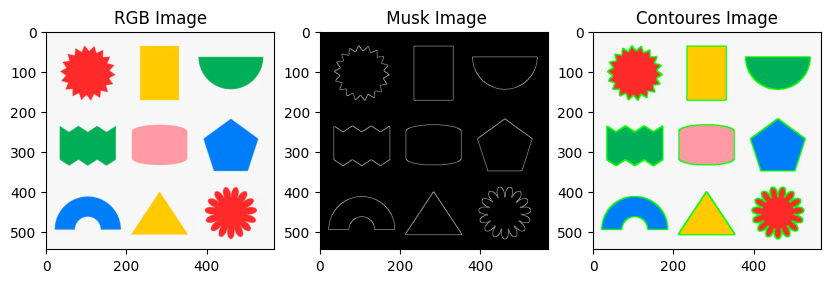

In [21]:
"""" 
cv2.drawContours(contours_image, contours, index, coolor, thickness) 

index = -1 means all index should be print

"""

contours_image = image.copy()

cv2.drawContours(contours_image, contours, -1, (0, 255, 0), 2)

contours_rgb = cv2.cvtColor(contours_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))


plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("RGB Image")

plt.subplot(1, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title(" Musk Image")

plt.subplot(1, 3, 3)
plt.imshow(contours_rgb)
plt.title("Contoures Image")


Text(0.5, 1.0, 'Contoures Image')

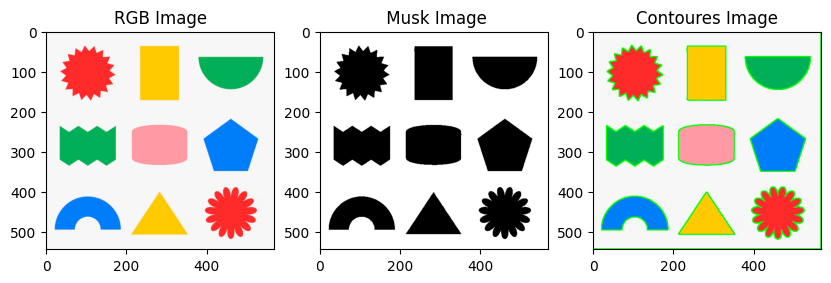

In [ ]:
"""" 
cv2.drawContours(contours_image, contours, index, coolor, thickness) 

index = -1 means all index should be print

"""
retval, thresh = cv2.threshold(image_gray, 200, 255, cv2.THRESH_BINARY)


contours, hierarchy = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

contours_image = image.copy()

cv2.drawContours(contours_image, contours, -1, (0, 255, 0), 2)

contours_rgb = cv2.cvtColor(contours_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))


plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("RGB Image")

plt.subplot(1, 3, 2)
plt.imshow(thresh, cmap="gray")
plt.title(" Musk Image")

plt.subplot(1, 3, 3)
plt.imshow(contours_rgb)
plt.title("Contoures Image")


### Practice another image

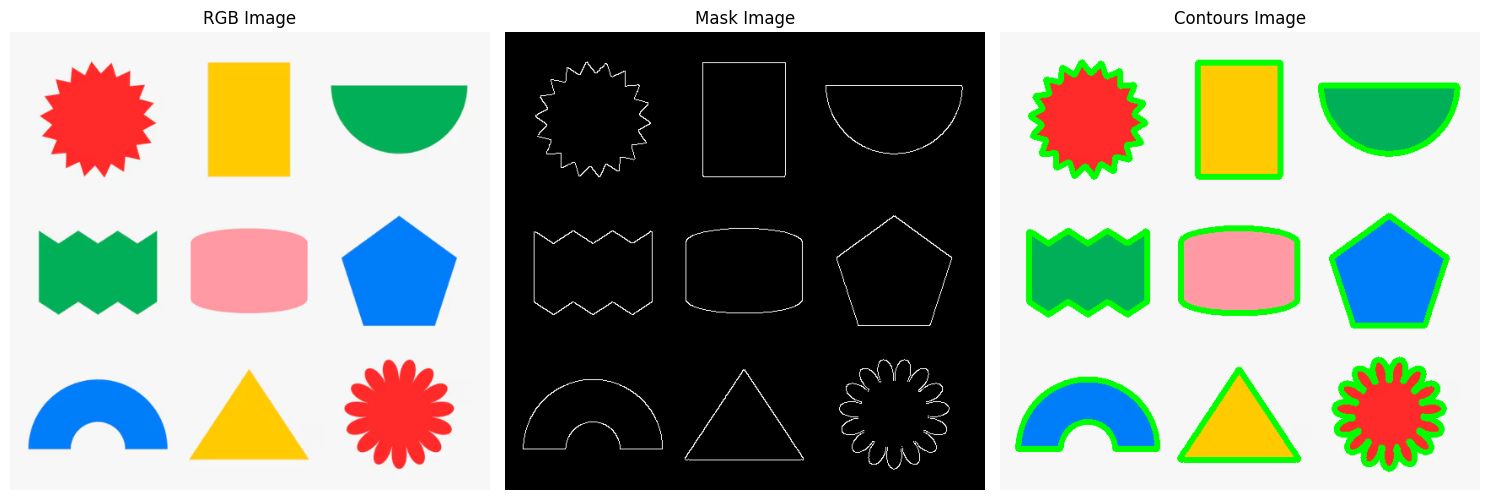

In [35]:
import cv2
import matplotlib.pyplot as plt

# Load BGR image
img = cv2.imread("./assets/shape2.png")

# Convert BGR to RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to Grayscale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Canny edge detection to get mask
mask_image = cv2.Canny(img_gray, 80, 150)

# Find contours
contours, hierarchy = cv2.findContours(mask_image, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

# Copy original image to draw contours
contours_img = img.copy()

# Draw contours on the image
cv2.drawContours(contours_img, contours, -1, (0, 255, 0), 5)

# Convert to RGB for matplotlib
contours_rgb_img = cv2.cvtColor(contours_img, cv2.COLOR_BGR2RGB)

# Plotting
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("RGB Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_image, cmap="gray")
plt.title("Mask Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(contours_rgb_img)
plt.title("Contours Image")
plt.axis("off")

plt.tight_layout()
plt.show()


In [79]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load BGR image
img = cv2.imread("./assets/shape2.png")

image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to Grayscale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

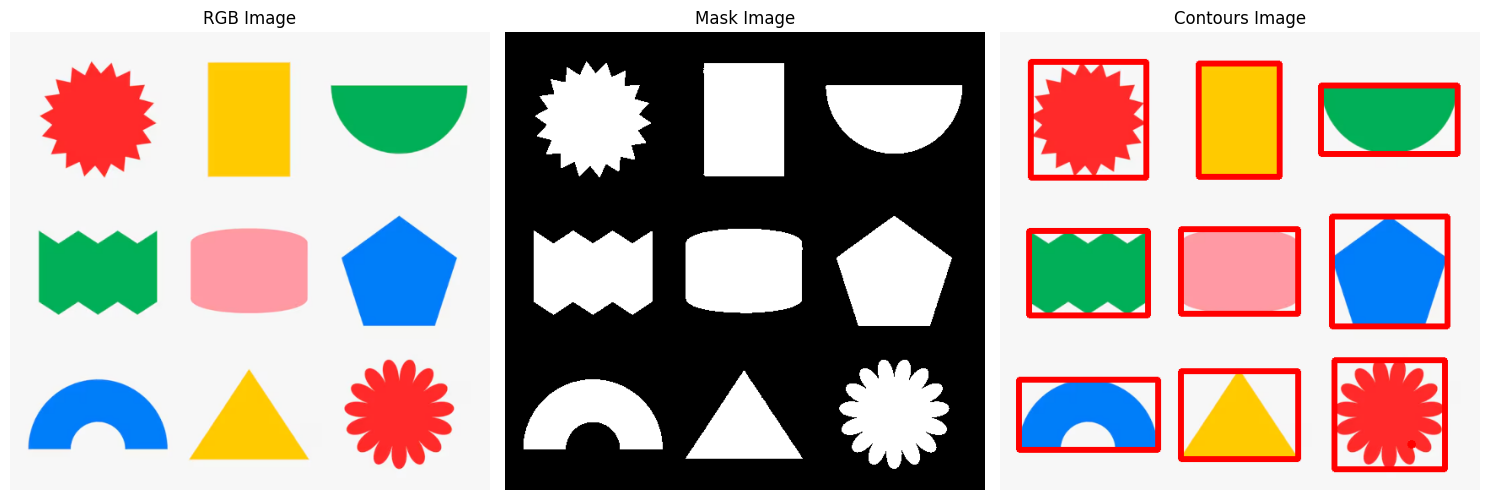

In [82]:
upper_bound = np.array([200], dtype=np.uint8)
lower_bound = np.array([90], dtype=np.uint8)

# Apply Canny edge detection to get mask
mask_image = cv2.inRange(img_gray, lower_bound, upper_bound)

# Find contours
contours, hierarchy = cv2.findContours(mask_image, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)

contours = sorted_contours[0:10]

for contour in contours:
    x,y,w,h = cv2.boundingRect(contour)
    cv2.rectangle(img, (x,y), (x+w, y+h), (0, 0, 255), 5)

# Convert to RGB for matplotlib
contours_rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Plotting
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("RGB Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_image, cmap="gray")
plt.title("Mask Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(contours_rgb_img)
plt.title("Contours Image")
plt.axis("off")

plt.tight_layout()
plt.show()